LINEAR REGRESSION
Manual:  a=2.306306, b=0.006757
Matrix:  a=2.306306, b=0.006757
Match:   True

POLYNOMIAL REGRESSION (Quadratic)
Y = 7.960481 + -0.153711X + 0.001076X²


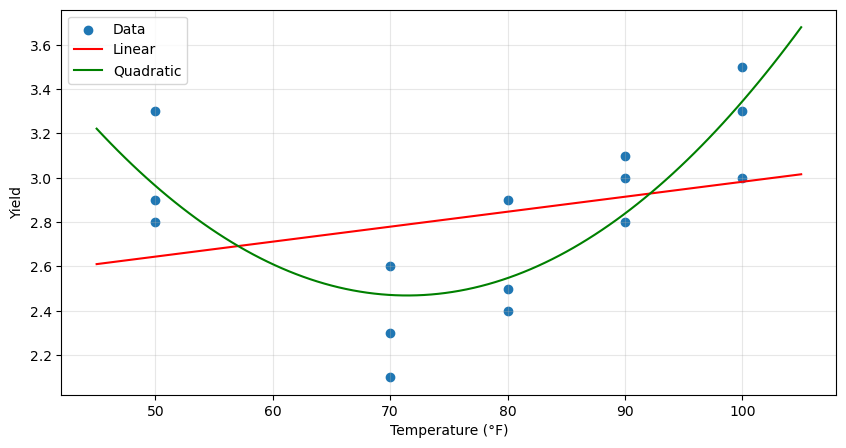


ERROR METRICS

LINEAR MODEL:
  MSE  = 0.132709
  RMSE = 0.364292

QUADRATIC MODEL:
  MSE  = 0.047785
  RMSE = 0.218597

IMPROVEMENT: 63.99% reduction in MSE


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# Part a: Create CSV file
def create_csv():
    data = {'Temp': [50,50,50,70,70,70,80,80,80,90,90,90,100,100,100],
            'Yield': [3.3,2.8,2.9,2.3,2.6,2.1,2.5,2.9,2.4,3.0,3.1,2.8,3.3,3.5,3.0]}
    df = pd.DataFrame(data)
    df.to_csv('yield_data.csv', index=False)
    return df

# Part b: Fit regression equations
def linear_regression(X, Y):
    n = len(X)
    b = (n*np.sum(X*Y) - np.sum(X)*np.sum(Y)) / (n*np.sum(X**2) - np.sum(X)**2)
    a = (np.sum(Y) - b*np.sum(X)) / n
    return a, b

def polynomial_regression(X, Y, degree=2):
    n = len(X)
    X_poly = np.column_stack([X**i for i in range(degree+1)])
    return np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ Y)

# Part c: Compare coefficients
def compare_methods(X, Y):
    # Manual method
    a_man, b_man = linear_regression(X, Y)
    
    # Matrix method
    X_mat = np.column_stack([np.ones(len(X)), X])
    a_mat, b_mat = np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ Y)
    
    print(f"Manual:  a={a_man:.6f}, b={b_man:.6f}")
    print(f"Matrix:  a={a_mat:.6f}, b={b_mat:.6f}")
    print(f"Match:   {np.allclose([a_man,b_man], [a_mat,b_mat])}")
    return a_man, b_man

# Part d: Plot
def plot_fits(X, Y, linear_coeffs, poly_coeffs):
    plt.figure(figsize=(10,5))
    plt.scatter(X, Y, label='Data')
    
    X_smooth = np.linspace(min(X)-5, max(X)+5, 100)
    
    # Linear fit
    plt.plot(X_smooth, linear_coeffs[0] + linear_coeffs[1]*X_smooth, 'r-', label='Linear')
    
    # Quadratic fit
    plt.plot(X_smooth, poly_coeffs[0] + poly_coeffs[1]*X_smooth + poly_coeffs[2]*X_smooth**2, 
             'g-', label='Quadratic')
    
    plt.xlabel('Temperature (°F)')
    plt.ylabel('Yield')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Part e: Compute errors
def compute_errors(Y, Y_pred):
    errors = Y - Y_pred
    mse = np.mean(errors**2)
    rmse = sqrt(mse)
    return errors, mse, rmse

# Main execution
def main():
    # Part a: Create CSV
    df = create_csv()
    X, Y = df['Temp'].values, df['Yield'].values
    
    # Part b & c: Fit and compare
    print("="*50)
    print("LINEAR REGRESSION")
    a, b = compare_methods(X, Y)
    
    print("\nPOLYNOMIAL REGRESSION (Quadratic)")
    poly_coeffs = polynomial_regression(X, Y, 2)
    print(f"Y = {poly_coeffs[0]:.6f} + {poly_coeffs[1]:.6f}X + {poly_coeffs[2]:.6f}X²")
    
    # Part d: Plot
    plot_fits(X, Y, [a,b], poly_coeffs)
    
    # Part e: Error metrics
    print("\n" + "="*50)
    print("ERROR METRICS")
    
    linear_pred = a + b*X
    poly_pred = poly_coeffs[0] + poly_coeffs[1]*X + poly_coeffs[2]*X**2
    
    _, linear_mse, linear_rmse = compute_errors(Y, linear_pred)
    _, poly_mse, poly_rmse = compute_errors(Y, poly_pred)
    
    print(f"\nLINEAR MODEL:")
    print(f"  MSE  = {linear_mse:.6f}")
    print(f"  RMSE = {linear_rmse:.6f}")
    
    print(f"\nQUADRATIC MODEL:")
    print(f"  MSE  = {poly_mse:.6f}")
    print(f"  RMSE = {poly_rmse:.6f}")
    
    print(f"\nIMPROVEMENT: {(linear_mse-poly_mse)/linear_mse*100:.2f}% reduction in MSE")

if __name__ == "__main__":
    main()

LINEAR REGRESSION
Manual:  intercept=2.306306, slope=0.006757
Matrix:  intercept=2.306306, slope=0.006757
Match:   True

POLYNOMIAL REGRESSION (Quadratic)
Y = 7.960481 + -0.153711X + 0.001076X²


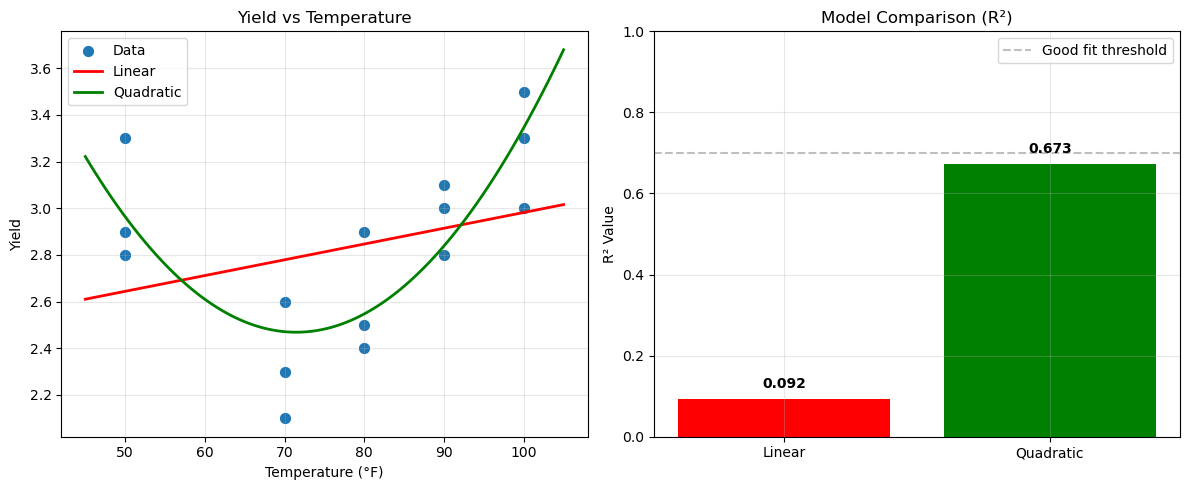


ERROR METRICS AND R²

LINEAR MODEL:
  MSE  = 0.132709
  RMSE = 0.364292
  R²   = 0.0924 (9.24%)
  Adj R² = 0.0226

QUADRATIC MODEL:
  MSE  = 0.047785
  RMSE = 0.218597
  R²   = 0.6732 (67.32%)
  Adj R² = 0.6481

IMPROVEMENT ANALYSIS
MSE Reduction:  63.99%
RMSE Reduction: 39.99%
R² Improvement: 58.08 percentage points

SUMMARY TABLE
Metric          Linear          Quadratic       Better Model   
------------------------------------------------------------
MSE             0.132709        0.047785        Quadratic      
RMSE            0.364292        0.218597        Quadratic      
R²              0.0924          0.6732          Quadratic      


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# Part a: Create CSV file
def create_csv():
    data = {'Temp': [50,50,50,70,70,70,80,80,80,90,90,90,100,100,100],
            'Yield': [3.3,2.8,2.9,2.3,2.6,2.1,2.5,2.9,2.4,3.0,3.1,2.8,3.3,3.5,3.0]}
    df = pd.DataFrame(data)
    df.to_csv('yield_data.csv', index=False)
    return df

# Part b: Fit regression equations
def linear_regression(X, Y):
    n = len(X)
    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_xy = np.sum(X * Y)
    sum_x2 = np.sum(X ** 2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    intercept = (sum_y - slope * sum_x) / n
    return intercept, slope

def polynomial_regression(X, Y, degree=2):
    X_poly = np.column_stack([X ** i for i in range(degree + 1)])
    coefficients = np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ Y)
    return coefficients

# Part c: Compare coefficients
def compare_methods(X, Y):
    # Manual method
    intercept_man, slope_man = linear_regression(X, Y)
    
    # Matrix method
    X_mat = np.column_stack([np.ones(len(X)), X])
    intercept_mat, slope_mat = np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ Y)
    
    print(f"Manual:  intercept={intercept_man:.6f}, slope={slope_man:.6f}")
    print(f"Matrix:  intercept={intercept_mat:.6f}, slope={slope_mat:.6f}")
    print(f"Match:   {np.allclose([intercept_man, slope_man], [intercept_mat, slope_mat])}")
    return intercept_man, slope_man

# Part d: Plot
def plot_fits(X, Y, linear_coeffs, poly_coeffs):
    plt.figure(figsize=(12,5))
    
    # First plot: Data with fits
    plt.subplot(1,2,1)
    plt.scatter(X, Y, label='Data', s=50)
    
    X_smooth = np.linspace(min(X) - 5, max(X) + 5, 100)
    
    # Linear fit
    intercept_lin = linear_coeffs[0]
    slope_lin = linear_coeffs[1]
    Y_lin_smooth = intercept_lin + slope_lin * X_smooth
    plt.plot(X_smooth, Y_lin_smooth, 'r-', label='Linear', linewidth=2)
    
    # Quadratic fit
    a0_poly = poly_coeffs[0]
    a1_poly = poly_coeffs[1]
    a2_poly = poly_coeffs[2]
    Y_poly_smooth = a0_poly + a1_poly * X_smooth + a2_poly * X_smooth ** 2
    plt.plot(X_smooth, Y_poly_smooth, 'g-', label='Quadratic', linewidth=2)
    
    plt.xlabel('Temperature (°F)')
    plt.ylabel('Yield')
    plt.title('Yield vs Temperature')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Second plot: R² comparison
    plt.subplot(1,2,2)
    
    # Calculate R² for both models
    Y_mean = np.mean(Y)
    
    Y_lin_pred = linear_coeffs[0] + linear_coeffs[1] * X
    Y_poly_pred = poly_coeffs[0] + poly_coeffs[1] * X + poly_coeffs[2] * X ** 2
    
    ssr_linear = np.sum((Y - Y_lin_pred) ** 2)
    ssr_poly = np.sum((Y - Y_poly_pred) ** 2)
    sst = np.sum((Y - Y_mean) ** 2)
    
    r2_linear = 1 - ssr_linear / sst
    r2_poly = 1 - ssr_poly / sst
    
    # Bar chart of R² values
    models = ['Linear', 'Quadratic']
    r2_values = [r2_linear, r2_poly]
    bars = plt.bar(models, r2_values, color=['red', 'green'])
    plt.ylim(0, 1)
    plt.ylabel('R² Value')
    plt.title('Model Comparison (R²)')
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='Good fit threshold')
    
    # Add R² values on bars
    for bar, r2_val in zip(bars, r2_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{r2_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Part e: Compute errors including R²
def compute_metrics(Y, Y_pred):
    # Basic errors
    errors = Y - Y_pred
    mse = np.mean(errors ** 2)
    rmse = sqrt(mse)
    
    # Calculate R²
    Y_mean = np.mean(Y)
    ssr = np.sum((Y - Y_pred) ** 2)
    sst = np.sum((Y - Y_mean) ** 2)
    r2 = 1 - (ssr / sst)
    
    # Adjusted R² (penalizes for extra variables)
    n = len(Y)
    p = 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return errors, mse, rmse, r2, adj_r2

# Main execution
def main():
    # Part a: Create CSV
    df = create_csv()
    X = df['Temp'].values
    Y = df['Yield'].values
    
    # Part b & c: Fit and compare
    print("=" * 60)
    print("LINEAR REGRESSION")
    intercept, slope = compare_methods(X, Y)
    
    print("\nPOLYNOMIAL REGRESSION (Quadratic)")
    poly_coeffs = polynomial_regression(X, Y, 2)
    print(f"Y = {poly_coeffs[0]:.6f} + {poly_coeffs[1]:.6f}X + {poly_coeffs[2]:.6f}X²")
    
    # Make predictions
    Y_lin_pred = intercept + slope * X
    Y_poly_pred = poly_coeffs[0] + poly_coeffs[1] * X + poly_coeffs[2] * X ** 2
    
    # Part d: Plot
    linear_coeffs = [intercept, slope]
    plot_fits(X, Y, linear_coeffs, poly_coeffs)
    
    # Part e: Error metrics with R²
    print("\n" + "=" * 60)
    print("ERROR METRICS AND R²")
    print("=" * 60)
    
    # Linear model metrics
    _, lin_mse, lin_rmse, lin_r2, lin_adj_r2 = compute_metrics(Y, Y_lin_pred)
    
    # Quadratic model metrics
    _, poly_mse, poly_rmse, poly_r2, poly_adj_r2 = compute_metrics(Y, Y_poly_pred)
    
    print("\nLINEAR MODEL:")
    print(f"  MSE  = {lin_mse:.6f}")
    print(f"  RMSE = {lin_rmse:.6f}")
    print(f"  R²   = {lin_r2:.4f} ({lin_r2 * 100:.2f}%)")
    print(f"  Adj R² = {lin_adj_r2:.4f}")
    
    print("\nQUADRATIC MODEL:")
    print(f"  MSE  = {poly_mse:.6f}")
    print(f"  RMSE = {poly_rmse:.6f}")
    print(f"  R²   = {poly_r2:.4f} ({poly_r2 * 100:.2f}%)")
    print(f"  Adj R² = {poly_adj_r2:.4f}")
    
    # Improvement metrics
    print("\n" + "=" * 60)
    print("IMPROVEMENT ANALYSIS")
    print("=" * 60)
    mse_reduction = (lin_mse - poly_mse) / lin_mse * 100
    rmse_reduction = (lin_rmse - poly_rmse) / lin_rmse * 100
    r2_improvement = (poly_r2 - lin_r2) * 100
    
    print(f"MSE Reduction:  {mse_reduction:.2f}%")
    print(f"RMSE Reduction: {rmse_reduction:.2f}%")
    print(f"R² Improvement: {r2_improvement:.2f} percentage points")
    
    # Summary table
    print("\n" + "=" * 60)
    print("SUMMARY TABLE")
    print("=" * 60)
    print(f"{'Metric':<15} {'Linear':<15} {'Quadratic':<15} {'Better Model':<15}")
    print("-" * 60)
    
    better_mse = 'Quadratic' if poly_mse < lin_mse else 'Linear'
    better_rmse = 'Quadratic' if poly_rmse < lin_rmse else 'Linear'
    better_r2 = 'Quadratic' if poly_r2 > lin_r2 else 'Linear'
    
    print(f"{'MSE':<15} {lin_mse:<15.6f} {poly_mse:<15.6f} {better_mse:<15}")
    print(f"{'RMSE':<15} {lin_rmse:<15.6f} {poly_rmse:<15.6f} {better_rmse:<15}")
    print(f"{'R²':<15} {lin_r2:<15.4f} {poly_r2:<15.4f} {better_r2:<15}")

if __name__ == "__main__":
    main()

LINEAR REGRESSION
Manual:  a=2.306306, b=0.006757
Matrix:  a=2.306306, b=0.006757
Match:   True

POLYNOMIAL REGRESSION (Quadratic)
Y = 7.960481 + -0.153711X + 0.001076X²


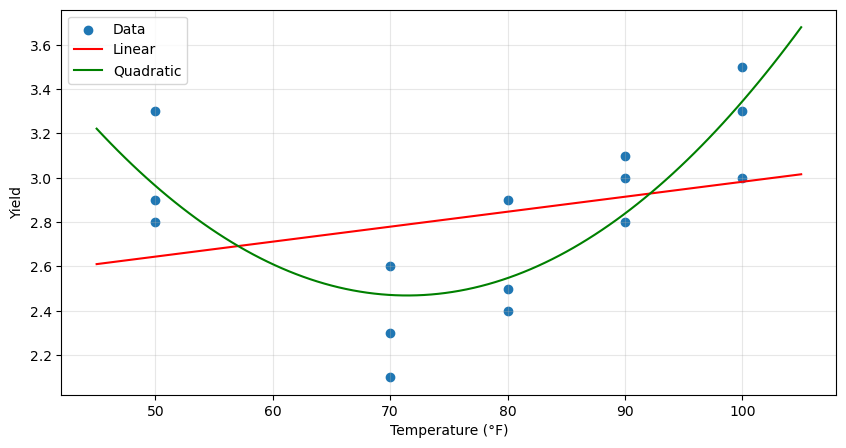


ERROR METRICS

LINEAR MODEL:
  MSE  = 0.132709
  RMSE = 0.364292

QUADRATIC MODEL:
  MSE  = 0.047785
  RMSE = 0.218597


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# Part a: Create CSV file
def create_csv():
    data = {'Temp': [50,50,50,70,70,70,80,80,80,90,90,90,100,100,100],
            'Yield': [3.3,2.8,2.9,2.3,2.6,2.1,2.5,2.9,2.4,3.0,3.1,2.8,3.3,3.5,3.0]}
    df = pd.DataFrame(data)
    df.to_csv('yield_data.csv', index=False)
    return df

# Part b: Fit regression equations
def linear_regression(X, Y):
    n = len(X)
    b = (n*np.sum(X*Y) - np.sum(X)*np.sum(Y)) / (n*np.sum(X**2) - np.sum(X)**2)
    a = (np.sum(Y) - b*np.sum(X)) / n
    return a, b

def polynomial_regression(X, Y, degree=2):
    X_poly = np.column_stack([X**i for i in range(degree+1)])
    return np.linalg.solve(X_poly.T @ X_poly, X_poly.T @ Y)

# Part c: Compare coefficients
def compare_methods(X, Y):
    # Manual method
    a_man, b_man = linear_regression(X, Y)
    
    # Matrix method
    X_mat = np.column_stack([np.ones(len(X)), X])
    a_mat, b_mat = np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ Y)
    
    print(f"Manual:  a={a_man:.6f}, b={b_man:.6f}")
    print(f"Matrix:  a={a_mat:.6f}, b={b_mat:.6f}")
    print(f"Match:   {np.allclose([a_man,b_man], [a_mat,b_mat])}")
    return a_man, b_man

# Part d: Plot
def plot_fits(X, Y, linear_coeffs, poly_coeffs):
    plt.figure(figsize=(10,5))
    plt.scatter(X, Y, label='Data')
    
    X_smooth = np.linspace(min(X)-5, max(X)+5, 100)
    
    # Linear fit
    plt.plot(X_smooth, linear_coeffs[0] + linear_coeffs[1]*X_smooth, 'r-', label='Linear')
    
    # Quadratic fit
    plt.plot(X_smooth, poly_coeffs[0] + poly_coeffs[1]*X_smooth + poly_coeffs[2]*X_smooth**2, 
             'g-', label='Quadratic')
    
    plt.xlabel('Temperature (°F)')
    plt.ylabel('Yield')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Part e: Compute errors
def compute_errors(Y, Y_pred):
    errors = Y - Y_pred
    mse = np.mean(errors**2)
    rmse = sqrt(mse)
    return errors, mse, rmse

# Main execution
def main():
    # Part a: Create CSV
    df = create_csv()
    X, Y = df['Temp'].values, df['Yield'].values
    
    # Part b & c: Fit and compare
    print("="*50)
    print("LINEAR REGRESSION")
    a, b = compare_methods(X, Y)
    
    print("\nPOLYNOMIAL REGRESSION (Quadratic)")
    poly_coeffs = polynomial_regression(X, Y, 2)
    print(f"Y = {poly_coeffs[0]:.6f} + {poly_coeffs[1]:.6f}X + {poly_coeffs[2]:.6f}X²")
    
    # Part d: Plot
    plot_fits(X, Y, [a,b], poly_coeffs)
    
    # Part e: Error metrics
    print("\n" + "="*50)
    print("ERROR METRICS")
    
    linear_pred = a + b*X
    poly_pred = poly_coeffs[0] + poly_coeffs[1]*X + poly_coeffs[2]*X**2
    
    _, linear_mse, linear_rmse = compute_errors(Y, linear_pred)
    _, poly_mse, poly_rmse = compute_errors(Y, poly_pred)
    
    print(f"\nLINEAR MODEL:")
    print(f"  MSE  = {linear_mse:.6f}")
    print(f"  RMSE = {linear_rmse:.6f}")
    
    print(f"\nQUADRATIC MODEL:")
    print(f"  MSE  = {poly_mse:.6f}")
    print(f"  RMSE = {poly_rmse:.6f}")

if __name__ == "__main__":
    main()